# Import Necessary Modules

In [1]:
import whisper #https://openai.com/research/whisper
import datetime

import subprocess

import torch
from pyannote.audio.pipelines.speaker_verification import PretrainedSpeakerEmbedding
from pyannote.audio import Audio
from pyannote.core import Segment

import wave
import contextlib

from sklearn.cluster import AgglomerativeClustering
import numpy as np
from scipy.io import wavfile

import matplotlib.pyplot as plt


The torchaudio backend is switched to 'soundfile'. Note that 'sox_io' is not supported on Windows.
torchvision is not available - cannot save figures
The torchaudio backend is switched to 'soundfile'. Note that 'sox_io' is not supported on Windows.
[NeMo W 2024-03-23 00:13:40 transformer_bpe_models:59] Could not import NeMo NLP collection which is required for speech translation model.


# Define Few Variables

In [2]:
# speaker_count = 2
speaker_count = 5

language = 'English'
model_size = 'tiny'

# Load Embedding Model

In [3]:
#https://github.com/speechbrain/speechbrain/tree/develop/recipes/VoxCeleb/SpeakerRec
embedding_model = PretrainedSpeakerEmbedding("speechbrain/spkrec-ecapa-voxceleb",device=torch.device("cpu"))

In [4]:
# path = "audio.wav"
path = "../utils/audioFiles/long_audio_files/5_Speaker_3mins.wav"
# path = "mc1.mp3"

In [5]:
if path[-3:] != 'wav':
  subprocess.call(['ffmpeg', '-i', path, 'audio.wav', '-y'])
  
else:
  fs, data = wavfile.read(path)
  try:
    wavfile.write('audio.wav', fs, data[:, 0])
  except:
    wavfile.write('audio.wav', fs, data[:])

path = 'audio.wav'

# Load Whisper Model for Speech to Text

In [6]:
model = whisper.load_model(model_size)#Speech to Text Model
result = model.transcribe(path)
segments = result["segments"]

# Read Audio File

In [7]:
wav_file = wave.open(path,'r')
with contextlib.closing(wav_file) as f:
  frames = f.getnframes()
  rate = f.getframerate()
  duration = frames / float(rate)

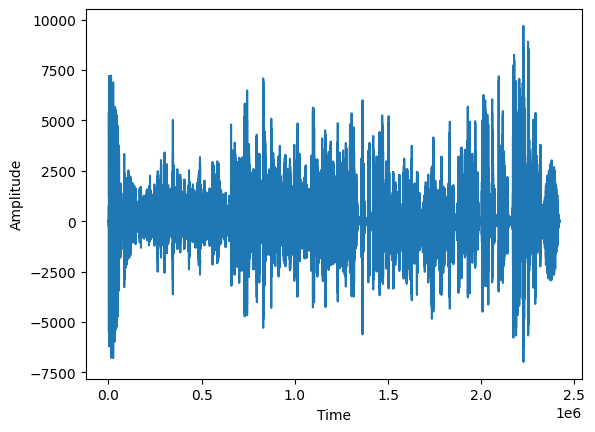

In [8]:
fs, data = wavfile.read(path)
plt.plot(data[0:])
plt.ylabel("Amplitude")
plt.xlabel("Time")
plt.show()

# Function to Embed Audio in suitale Type and Size

In [9]:
audio = Audio()

def segment_embedding(segment):
  start = segment["start"]
  # Whisper overshoots the end timestamp in the last segment
  end = min(duration, segment["end"])
  clip = Segment(start, end)
  waveform, sample_rate = audio.crop(path, clip)
  wavform = waveform[None]
  embd_mdl = embedding_model(wavform)
  return embd_mdl

In [10]:
embeddings = np.zeros(shape=(len(segments), 192))

# Get all Segments of Audio

In [11]:

for s_no, segment in enumerate(segments):
  print(s_no, segment)
  embd = segment_embedding(segment)
  embeddings[s_no] = embd

0 {'id': 0, 'seek': 0, 'start': 0.0, 'end': 10.0, 'text': " I think if you're a leader and you don't understand the terms that you're using, that's probably the first start.", 'tokens': [50364, 286, 519, 498, 291, 434, 257, 5263, 293, 291, 500, 380, 1223, 264, 2115, 300, 291, 434, 1228, 11, 300, 311, 1391, 264, 700, 722, 13, 50864], 'temperature': 0.0, 'avg_logprob': -0.18397505204756182, 'compression_ratio': 1.6582278481012658, 'no_speech_prob': 0.05561544746160507}
1 {'id': 1, 'seek': 0, 'start': 10.0, 'end': 16.0, 'text': " It's really important that as a leader in the organisation, you understand what the digitization means.", 'tokens': [50864, 467, 311, 534, 1021, 300, 382, 257, 5263, 294, 264, 18641, 11, 291, 1223, 437, 264, 14293, 2144, 1355, 13, 51164], 'temperature': 0.0, 'avg_logprob': -0.18397505204756182, 'compression_ratio': 1.6582278481012658, 'no_speech_prob': 0.05561544746160507}
2 {'id': 2, 'seek': 0, 'start': 16.0, 'end': 26.0, 'text': ' You take the time to read wide

# Convert Audio Segments to Embedded Type for Clustering

In [12]:
embeddings = np.nan_to_num(embeddings)

# Apply Agglomerative Clustering

In [13]:
clustering = AgglomerativeClustering(speaker_count).fit(embeddings)


labels = clustering.labels_
for i in range(len(segments)):
  segments[i]["speaker"] = 'SPEAKER ' + str(labels[i] + 1)
  print(segments[i]["speaker"], segments[i])

SPEAKER 2 {'id': 0, 'seek': 0, 'start': 0.0, 'end': 10.0, 'text': " I think if you're a leader and you don't understand the terms that you're using, that's probably the first start.", 'tokens': [50364, 286, 519, 498, 291, 434, 257, 5263, 293, 291, 500, 380, 1223, 264, 2115, 300, 291, 434, 1228, 11, 300, 311, 1391, 264, 700, 722, 13, 50864], 'temperature': 0.0, 'avg_logprob': -0.18397505204756182, 'compression_ratio': 1.6582278481012658, 'no_speech_prob': 0.05561544746160507, 'speaker': 'SPEAKER 2'}
SPEAKER 2 {'id': 1, 'seek': 0, 'start': 10.0, 'end': 16.0, 'text': " It's really important that as a leader in the organisation, you understand what the digitization means.", 'tokens': [50864, 467, 311, 534, 1021, 300, 382, 257, 5263, 294, 264, 18641, 11, 291, 1223, 437, 264, 14293, 2144, 1355, 13, 51164], 'temperature': 0.0, 'avg_logprob': -0.18397505204756182, 'compression_ratio': 1.6582278481012658, 'no_speech_prob': 0.05561544746160507, 'speaker': 'SPEAKER 2'}
SPEAKER 2 {'id': 2, 'seek':

# Save the Output to output.txt

In [14]:
def time(secs):
  return datetime.timedelta(seconds=secs)

f = open("output.txt", "w")
for (i, segment) in enumerate(segments):
  if i == 0 or segments[i - 1]["speaker"] != segment["speaker"]:
    f.write("\n" + segment["speaker"] + ' ' + str(time(segment["start"])) + " ---> " + str(time(segment["end"])) + '\n')
  f.write(segment["text"][1:] + ' ')
f.close()

# Plot Points for all Audio Chunks

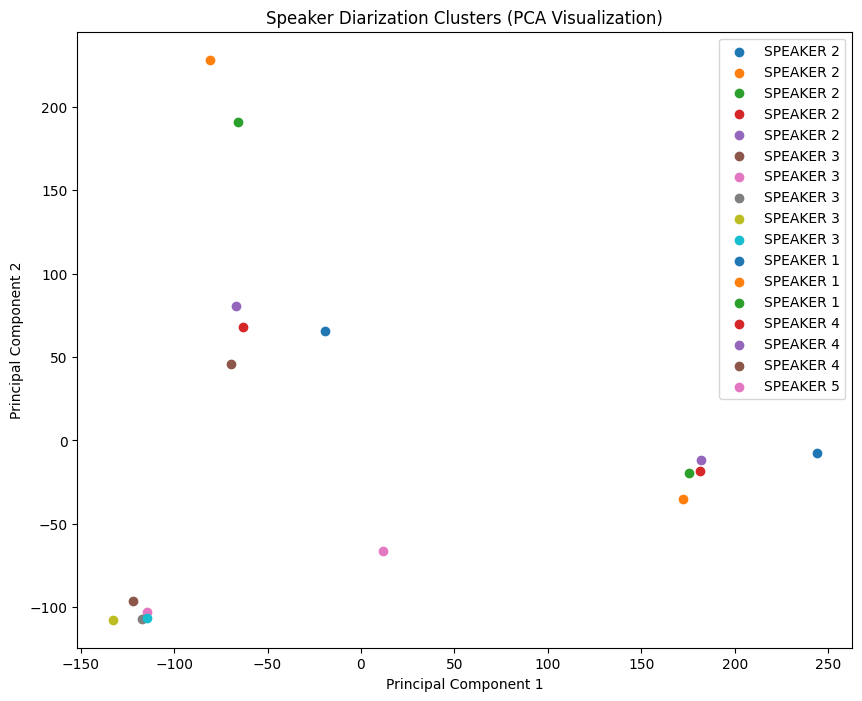

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# existing code for clustering and labeling segments...

# Perform PCA to reduce the dimensionality of embeddings to 2D
pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(embeddings)

# Plot the clusters
plt.figure(figsize=(10, 8))
for i, segment in enumerate(segments):
    speaker_id = labels[i] + 1
    x, y = embeddings_2d[i]
    plt.scatter(x, y, label=f'SPEAKER {speaker_id}')

plt.title("Speaker Diarization Clusters (PCA Visualization)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

# Audio Data Points at Right side of Graph is by Speaker 1 and Left side Graph is by Speaker 2

In [16]:
import numpy as np
import plotly.graph_objects as go
from sklearn.decomposition import PCA
import matplotlib.cm as cm

# existing code for clustering and labeling segments...

# Perform PCA to reduce the dimensionality of embeddings to 3D
pca = PCA(n_components=3, random_state=42)
embeddings_3d = pca.fit_transform(embeddings)

# Get the number of unique speakers from the labels
num_unique_speakers = len(np.unique(labels))

# Create a colormap for speakers, ensuring each speaker gets a unique color
colors = cm.tab20b(np.linspace(0, 1, num_unique_speakers))

# Prepare the data for the 3D scatter plot
data = []
for i, segment in enumerate(segments):
    speaker_id = labels[i] + 1
    x, y, z = embeddings_3d[i]
    color = colors[labels[i] % num_unique_speakers]  # Get the corresponding color for the speaker
    trace = go.Scatter3d(x=[x], y=[y], z=[z], mode='markers',
                         marker=dict(size=5, color=color),
                         name=f'SPEAKER {speaker_id}')
    data.append(trace)

# Layout for the 3D scatter plot
layout = go.Layout(
    title="Speaker Diarization Clusters (3D Visualization)",
    scene=dict(
        xaxis_title="Principal Component 1",
        yaxis_title="Principal Component 2",
        zaxis_title="Principal Component 3"
    )
)

# Create the figure and plot the 3D scatter plot
fig = go.Figure(data=data, layout=layout)
fig.show()